In [4]:
import pandas as pd

df = pd.read_csv('../data/online_retail_clean.csv', parse_dates=['InvoiceDate'])

fecha_corte = pd.Timestamp('2011-09-01')

df_features_window = df[df['InvoiceDate'] < fecha_corte]
df_prediction_window = df[df['InvoiceDate'] >= fecha_corte]

print(f"Ventana de features: {df_features_window['InvoiceDate'].min()} a {df_features_window['InvoiceDate'].max()}")
print(f"Clientes en ventana de features: {df_features_window['Customer ID'].nunique()}")
print(f"Ventana de predicción: {df_prediction_window['InvoiceDate'].min()} a {df_prediction_window['InvoiceDate'].max()}")

C:\Users\juanr\AppData\Local\Temp\ipykernel_6356\4123267336.py:3: DtypeWarning: Columns (0: Invoice) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/online_retail_clean.csv', parse_dates=['InvoiceDate'])


Ventana de features: 2009-12-01 07:45:00 a 2011-08-31 17:30:00
Clientes en ventana de features: 5249
Ventana de predicción: 2011-09-01 08:25:00 a 2011-12-09 12:50:00


In [5]:
df_rfm = df_features_window[df_features_window['Customer ID'].notna()].copy()

rfm = df_rfm.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (fecha_corte - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('Revenue', 'sum'),
    FirstPurchase=('InvoiceDate', 'min'),
    UniqueProducts=('StockCode', 'nunique'),
    AvgBasketSize=('Quantity', 'mean')
)

rfm['Tenure'] = (fecha_corte - rfm['FirstPurchase']).dt.days
rfm['AvgOrderValue'] = rfm['Monetary'] / rfm['Frequency']
rfm = rfm.drop(columns=['FirstPurchase'])

# Etiqueta: 1 = churn (no volvió a comprar), 0 = se quedó
clientes_que_volvieron = set(df_prediction_window['Customer ID'].dropna().unique())
rfm['Churn'] = (~rfm.index.isin(clientes_que_volvieron)).astype(int)

print(rfm['Churn'].value_counts(normalize=True))
print(rfm.head())

Churn
1    0.553439
0    0.446561
Name: proportion, dtype: float64
             Recency  Frequency  Monetary  UniqueProducts  AvgBasketSize  \
Customer ID                                                                
12346.0          225         12  77556.46              27    2184.852941   
12347.0           29          6   3402.39             107      12.798780   
12348.0          148          4   1709.40              25      52.020833   
12349.0          307          3   2671.14              90       9.735294   
12350.0          210          1    334.40              17      11.588235   

             Tenure  AvgOrderValue  Churn  
Customer ID                                
12346.0         625    6463.038333      1  
12347.0         304     567.065000      0  
12348.0         338     427.350000      0  
12349.0         489     890.380000      0  
12350.0         210     334.400000      1  


In [6]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

X = rfm.drop(columns=['Churn'])
y = rfm['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

modelos = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

for nombre, modelo in modelos.items():
    datos_entrenamiento = X_train_scaled if nombre == 'Logistic Regression' else X_train
    scores = cross_val_score(modelo, datos_entrenamiento, y_train, cv=5, scoring='roc_auc')
    print(f"{nombre}: ROC-AUC promedio = {scores.mean():.4f} (+/- {scores.std():.4f})")

Logistic Regression: ROC-AUC promedio = 0.7912 (+/- 0.0087)
Random Forest: ROC-AUC promedio = 0.7841 (+/- 0.0118)
XGBoost: ROC-AUC promedio = 0.7675 (+/- 0.0133)


In [7]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print(f"Mejor C: {grid_search.best_params_}")
print(f"Mejor ROC-AUC (validación cruzada): {grid_search.best_score_:.4f}")

Mejor C: {'C': 10}
Mejor ROC-AUC (validación cruzada): 0.7913


In [8]:
from sklearn.metrics import roc_auc_score, classification_report

mejor_modelo = grid_search.best_estimator_
X_test_scaled = scaler.transform(X_test)

y_pred_proba = mejor_modelo.predict_proba(X_test_scaled)[:, 1]
y_pred = mejor_modelo.predict(X_test_scaled)

print(f"ROC-AUC en test: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(classification_report(y_test, y_pred))

ROC-AUC en test: 0.8145
              precision    recall  f1-score   support

           0       0.72      0.69      0.70       469
           1       0.76      0.78      0.77       581

    accuracy                           0.74      1050
   macro avg       0.74      0.74      0.74      1050
weighted avg       0.74      0.74      0.74      1050



Background dataset has 4199 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=4199 when initializing the masker.


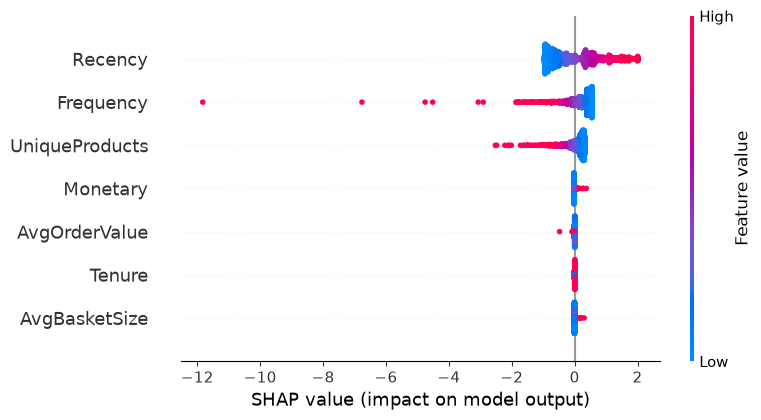

In [9]:
import shap

explainer = shap.LinearExplainer(mejor_modelo, X_train_scaled)
shap_values = explainer(X_test_scaled)

shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist())

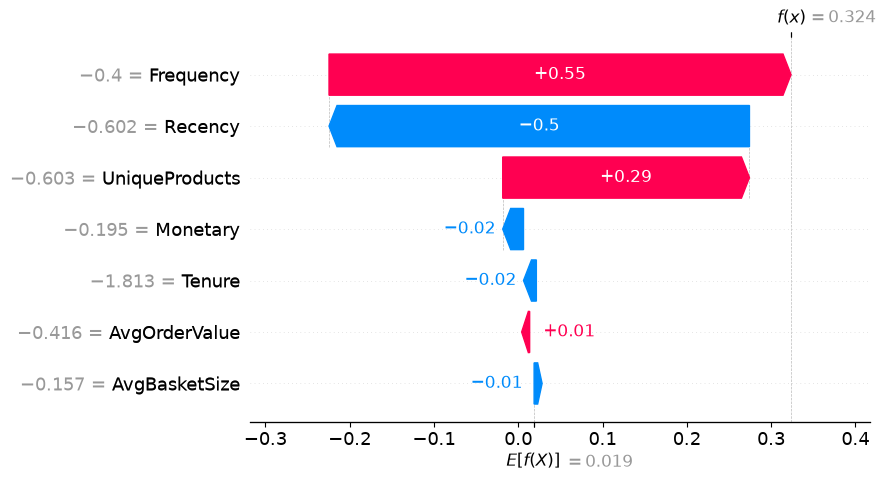

Cliente: 13972.0
Probabilidad de churn predicha: 58.02%
Churn real: 0
Recency           101.000000
Frequency           1.000000
Monetary          145.900000
UniqueProducts      9.000000
AvgBasketSize       4.666667
Tenure            101.000000
AvgOrderValue     145.900000
Name: 13972.0, dtype: float64


In [ ]:
import shap

shap_values.feature_names = X.columns.tolist()

idx = 0
shap.plots.waterfall(shap_values[idx])

print(f"Cliente: {X_test.index[idx]}")
print(f"Probabilidad de churn predicha: {y_pred_proba[idx]:.2%}")
print(f"Churn real: {y_test.iloc[idx]}")


In [11]:
import joblib
import os

os.makedirs('../api/model', exist_ok=True)
joblib.dump(mejor_modelo, '../api/model/modelo_churn.pkl')
joblib.dump(scaler, '../api/model/scaler.pkl')
print("Modelo y scaler guardados")

Modelo y scaler guardados


In [12]:
print(X_test.loc[13972.0])

Recency           101.000000
Frequency           1.000000
Monetary          145.900000
UniqueProducts      9.000000
AvgBasketSize       4.666667
Tenure            101.000000
AvgOrderValue     145.900000
Name: 13972.0, dtype: float64
